### **Разведочный анализ данных**
Пока просто смотрим данные

In [16]:
import pandas as pd
import logging
import coloredlogs
import seaborn as sns

logger = logging.getLogger(__name__)
coloredlogs.install(level='INFO', logger=logger, fmt='%(asctime)s [%(levelname)s] %(message)s',
                    level_styles={'info': {'color': 'green'}, 'error': {'color': 'red', 'bold': True}})

In [17]:
%%time

DATA_PATH = 'C:/vs_code_projects/distributed-churn-prediction/data/Train.csv'
    
df = pd.read_csv(
    filepath_or_buffer=DATA_PATH,
    sep=',',
    encoding='utf-8',
    na_values=['', 'N/A', 'n/a', 'NULL', 'null', 'Null', ' ', 'nan', 'None'])

if df.empty:
    logger.error(f'Не удалось загрузить данные из файла {DATA_PATH}')
    raise Exception(f'Не удалось загрузить данные из файла {DATA_PATH}')
else:
    logger.info(f'Данные из файла {DATA_PATH} успешно загружены в переменную df')

2026-02-26 20:01:16 [INFO] Данные из файла C:/vs_code_projects/distributed-churn-prediction/data/Train.csv успешно загружены в переменную df


CPU times: total: 8.98 s
Wall time: 9.65 s


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2154048 entries, 0 to 2154047
Data columns (total 19 columns):
 #   Column          Dtype  
---  ------          -----  
 0   user_id         str    
 1   REGION          str    
 2   TENURE          str    
 3   MONTANT         float64
 4   FREQUENCE_RECH  float64
 5   REVENUE         float64
 6   ARPU_SEGMENT    float64
 7   FREQUENCE       float64
 8   DATA_VOLUME     float64
 9   ON_NET          float64
 10  ORANGE          float64
 11  TIGO            float64
 12  ZONE1           float64
 13  ZONE2           float64
 14  MRG             str    
 15  REGULARITY      int64  
 16  TOP_PACK        str    
 17  FREQ_TOP_PACK   float64
 18  CHURN           int64  
dtypes: float64(12), int64(2), str(5)
memory usage: 459.3 MB


In [3]:
df.columns

Index(['user_id', 'REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE',
       'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
       'ZONE1', 'ZONE2', 'MRG', 'REGULARITY', 'TOP_PACK', 'FREQ_TOP_PACK',
       'CHURN'],
      dtype='str')

In [4]:
for col in df.columns:
    na_count = df[col].isna().sum()
    print(f'Кол-во пропусков в колонке {col} = {na_count}, частота пропусков {na_count * 100 / df.shape[0]:.2f}%')

Кол-во пропусков в колонке user_id = 0, частота пропусков 0.00%
Кол-во пропусков в колонке REGION = 849299, частота пропусков 39.43%
Кол-во пропусков в колонке TENURE = 0, частота пропусков 0.00%
Кол-во пропусков в колонке MONTANT = 756739, частота пропусков 35.13%
Кол-во пропусков в колонке FREQUENCE_RECH = 756739, частота пропусков 35.13%
Кол-во пропусков в колонке REVENUE = 726048, частота пропусков 33.71%
Кол-во пропусков в колонке ARPU_SEGMENT = 726048, частота пропусков 33.71%
Кол-во пропусков в колонке FREQUENCE = 726048, частота пропусков 33.71%
Кол-во пропусков в колонке DATA_VOLUME = 1060433, частота пропусков 49.23%
Кол-во пропусков в колонке ON_NET = 786675, частота пропусков 36.52%
Кол-во пропусков в колонке ORANGE = 895248, частота пропусков 41.56%
Кол-во пропусков в колонке TIGO = 1290016, частота пропусков 59.89%
Кол-во пропусков в колонке ZONE1 = 1984327, частота пропусков 92.12%
Кол-во пропусков в колонке ZONE2 = 2017224, частота пропусков 93.65%
Кол-во пропусков в ко

In [5]:
# Какие это значения?
df['TOP_PACK'].unique()

<ArrowStringArray>
[           'On net 200F=Unlimited _call24H',
                                         nan,
                   'On-net 1000F=10MilF;10d',
                         'Data:1000F=5GB,7d',
               'Mixt 250F=Unlimited_call24H',
 'MIXT:500F= 2500F on net _2500F off net;2d',
                     'All-net 500F=2000F;5d',
                        'On-net 500F_FNF;3d',
                      'Data: 100 F=40MB,24H',
   'MIXT: 200mnoff net _unl on net _5Go;30d',
 ...
                   'Data:New-GPRS_PKG_1500F',
                       'GPRS_BKG_1000F MIFI',
                  'Data:OneTime_Pilot_1.5GB',
                           'FIFA_TS_monthly',
                     'GPRS_PKG_5GO_ILLIMITE',
                            'Data_Mifi_20Go',
                           'APANews_monthly',
    'NEW_CLIR_TEMPRESTRICTED_LIBERTE_MOBILE',
                        'GPRS_5Go_7D_PORTAL',
                          'Package3_Monthly']
Length: 141, dtype: str

In [6]:
# какова статистика распределения этих значений? (сколько каких значений)
stat = df['TOP_PACK'].value_counts(normalize=False)

n = 10

print(f'Тарифы, где более {n} абонентов: {stat[stat > n].shape[0] * 100 / stat.shape[0]:.2f}%')
stat

Тарифы, где более 10 абонентов: 66.43%


TOP_PACK
All-net 500F=2000F;5d                     317802
On net 200F=Unlimited _call24H            152295
Data:490F=1GB,7d                          115180
Data: 100 F=40MB,24H                       84649
Mixt 250F=Unlimited_call24H                67512
                                           ...  
Data_Mifi_20Go                                 1
APANews_monthly                                1
NEW_CLIR_TEMPRESTRICTED_LIBERTE_MOBILE         1
GPRS_5Go_7D_PORTAL                             1
Package3_Monthly                               1
Name: count, Length: 140, dtype: int64

In [7]:
# исследование целевого (target) признака - факта ухода клиента 
print('кол-во уникальных значений в таргете: ', df['CHURN'].nunique())
print('перечень уникальных значений в таргете: ', df['CHURN'].unique())
print('статистика распределения значений в таргете: \n', df['CHURN'].value_counts(normalize=True))

кол-во уникальных значений в таргете:  2
перечень уникальных значений в таргете:  [0 1]
статистика распределения значений в таргете: 
 CHURN
0    0.812453
1    0.187547
Name: proportion, dtype: float64


In [8]:
# описательная статистика для признака Age
df['DATA_VOLUME'].describe()

count    1.093615e+06
mean     3.366450e+03
std      1.330446e+04
min      0.000000e+00
25%      0.000000e+00
50%      2.570000e+02
75%      2.895000e+03
max      1.823866e+06
Name: DATA_VOLUME, dtype: float64

In [9]:
# описательная статистика для всех (числовых) признаков
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MONTANT,1397309.0,5532.116998,7111.339421,10.0,1000.0,3000.0,7350.0,470000.0
FREQUENCE_RECH,1397309.0,11.529120,13.274070,1.0,2.0,7.0,16.0,133.0
REVENUE,1428000.0,5510.810334,7187.112880,1.0,1000.0,3000.0,7368.0,532177.0
ARPU_SEGMENT,1428000.0,1836.942894,2395.699954,0.0,333.0,1000.0,2456.0,177392.0
FREQUENCE,1428000.0,13.978141,14.694035,1.0,3.0,9.0,20.0,91.0
DATA_VOLUME,1093615.0,3366.450167,13304.463667,0.0,0.0,257.0,2895.0,1823866.0
ON_NET,1367373.0,277.689140,872.688909,0.0,5.0,27.0,156.0,50809.0
ORANGE,1258800.0,95.418711,204.987266,0.0,7.0,29.0,99.0,21323.0
TIGO,864032.0,23.109253,63.578086,0.0,2.0,6.0,20.0,4174.0
ZONE1,169721.0,8.170132,41.169511,0.0,0.0,1.0,3.0,4792.0


In [11]:
df.columns

Index(['user_id', 'REGION', 'TENURE', 'MONTANT', 'FREQUENCE_RECH', 'REVENUE',
       'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
       'ZONE1', 'ZONE2', 'MRG', 'REGULARITY', 'TOP_PACK', 'FREQ_TOP_PACK',
       'CHURN'],
      dtype='str')

In [13]:
features_eda = ['MONTANT', 'FREQUENCE_RECH', 'REVENUE',
       'ARPU_SEGMENT', 'FREQUENCE', 'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO',
       'ZONE1', 'ZONE2', 'REGULARITY', 'FREQ_TOP_PACK',
       'CHURN']

corr = df[features_eda].corr()
corr

,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK,CHURN
MONTANT,1.000000,0.792672,0.976558,0.976558,0.775650,0.297847,0.326999,0.658372,0.412611,0.373342,0.424086,0.522593,0.741021,-0.105046
FREQUENCE_RECH,0.792672,1.000000,0.800284,0.800283,0.956127,0.150433,0.404998,0.518992,0.343009,0.119758,0.133633,0.557745,0.868200,-0.123439
REVENUE,0.976558,0.800284,1.000000,1.000000,0.785681,0.304058,0.332212,0.661119,0.412409,0.380280,0.375807,0.532103,0.750840,-0.114079
ARPU_SEGMENT,0.976558,0.800283,1.000000,1.000000,0.785680,0.304058,0.332212,0.661120,0.412409,0.380280,0.375807,0.532102,0.750840,-0.114079
FREQUENCE,0.775650,0.956127,0.785681,0.785680,1.000000,0.166603,0.395035,0.471881,0.306875,0.109893,0.146487,0.591324,0.844373,-0.139363
DATA_VOLUME,0.297847,0.150433,0.304058,0.304058,0.166603,1.000000,-0.013524,0.063176,0.022689,0.036299,0.049496,0.182708,0.116006,-0.032422
ON_NET,0.326999,0.404998,0.332212,0.332212,0.395035,-0.013524,1.000000,0.219622,0.136773,0.004499,-0.014901,0.270357,0.356503,-0.058698
ORANGE,0.658372,0.518992,0.661119,0.661120,0.471881,0.063176,0.219622,1.000000,0.403425,0.052715,0.034348,0.309016,0.553416,-0.063400
TIGO,0.412611,0.343009,0.412409,0.412409,0.306875,0.022689,0.136773,0.403425,1.000000,0.013807,0.020846,0.194156,0.368844,-0.035668
ZONE1,0.373342,0.119758,0.380280,0.380280,0.109893,0.036299,0.004499,0.052715,0.013807,1.000000,0.083372,0.045649,0.204093,0.009724


<Axes: >

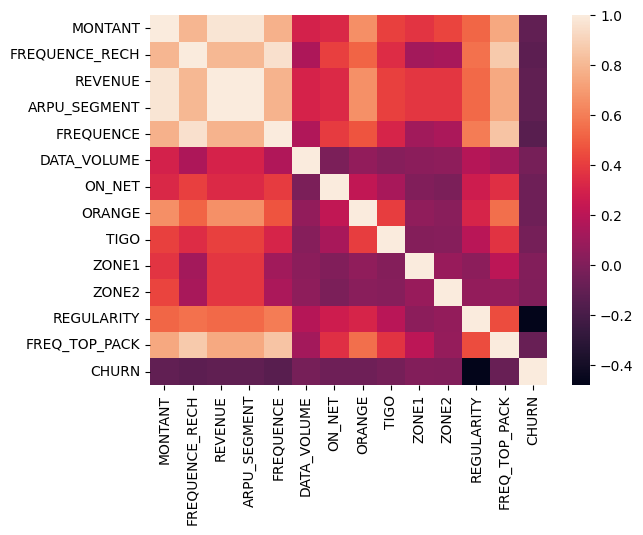

In [18]:
sns.heatmap(corr)

array([[<Axes: title={'center': 'MONTANT'}>,
        <Axes: title={'center': 'FREQUENCE_RECH'}>,
        <Axes: title={'center': 'REVENUE'}>,
        <Axes: title={'center': 'ARPU_SEGMENT'}>],
       [<Axes: title={'center': 'FREQUENCE'}>,
        <Axes: title={'center': 'DATA_VOLUME'}>,
        <Axes: title={'center': 'ON_NET'}>,
        <Axes: title={'center': 'ORANGE'}>],
       [<Axes: title={'center': 'TIGO'}>,
        <Axes: title={'center': 'ZONE1'}>,
        <Axes: title={'center': 'ZONE2'}>,
        <Axes: title={'center': 'REGULARITY'}>],
       [<Axes: title={'center': 'FREQ_TOP_PACK'}>,
        <Axes: title={'center': 'CHURN'}>, <Axes: >, <Axes: >]],
      dtype=object)

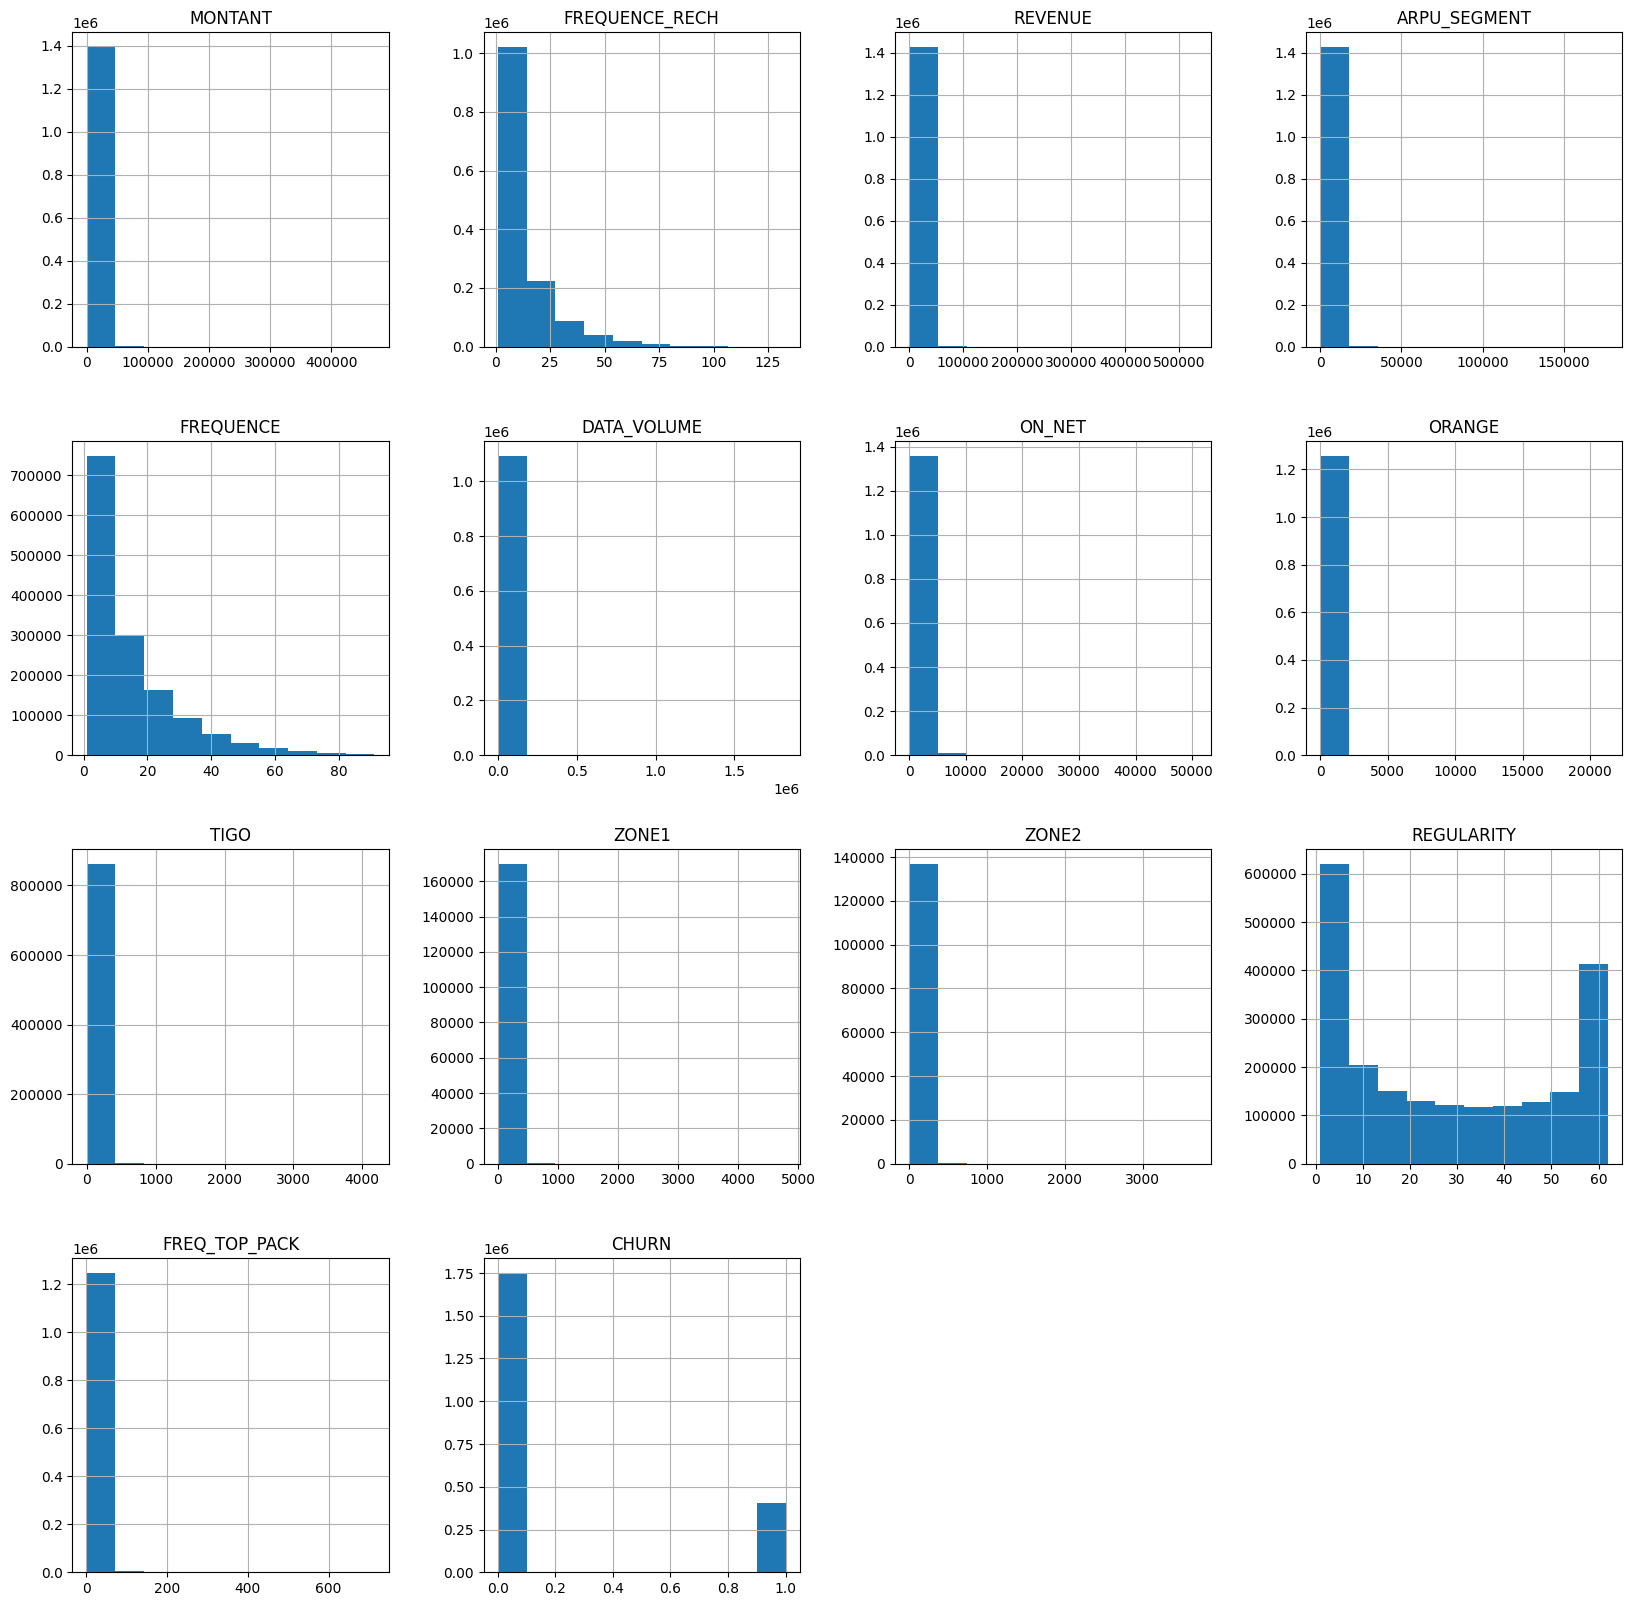

In [19]:
df.hist(figsize=(20,20))